In [25]:
# Cell 1: Setup & Imports
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np

# Add project root to sys.path
project_root = str(Path().cwd().resolve())
if "notebooks" in project_root:
    project_root = str(Path().cwd().parent.resolve())
if project_root not in sys.path:
    sys.path.append(project_root)

from core.data_fetcher.aligner import CrossSectionAligner
from backtest.evaluation import FactorEvaluator
from factors.momentum.reversal import ShortTermReversal
from factors.fundamental.f_score import PiotroskiFScore

In [26]:
# Cell 2: Load Processed Data & Mock Fundamentals
data_dict = {}
price_series_dict = {}

raw_dir = Path(project_root) / 'data' / 'processed'

print(f"Loading data from: {raw_dir}")

# Dynamically load all parquet files
for file_path in raw_dir.glob("*.parquet"):
    ticker = file_path.stem  # e.g., 'AAPL.US'
    
    try:
        df = pd.read_parquet(file_path)
        
        # Crucial Mocking Step: Add dummy fundamental columns
        # We need realistic-looking data for Piotroski F-Score to work
        n_rows = len(df)

        data_dict[ticker] = df
        
        # Extract close price for Alphalens forward return calculation
        if 'close' in df.columns:
            price_series_dict[ticker] = df['close']
            
    except Exception as e:
        print(f"Error loading {ticker}: {e}")

# Create wide DataFrame of price data (Dates x Tickers)
price_df = pd.DataFrame(price_series_dict)

print(f"Loaded {len(data_dict)} tickers into the universe.")
print(f"Price Matrix Shape: {price_df.shape}")

Loading data from: /Users/bytedance/workspace/factor_investment/data/processed
Loaded 503 tickers into the universe.
Price Matrix Shape: (4073, 503)


In [27]:
# 随便抽一只股票看看列名
sample_ticker = list(data_dict.keys())[0]
print(f"Columns for {sample_ticker}:")
print(data_dict[sample_ticker].columns.tolist())

Columns for GEHC.US:
['open', 'high', 'low', 'close', 'adjusted_close', 'volume', 'roa', 'cf_ops', 'leverage', 'current_ratio', 'shares_out', 'gross_margin', 'asset_turnover']


In [28]:
print(data_dict['CAT.US'][['roa', 'cf_ops', 'leverage']].notna().sum())

roa         4041
cf_ops      4041
leverage    4041
dtype: int64


In [29]:
# Cell 3: Calculate Factors
reversal_factor = ShortTermReversal(lookback_period=5)
f_score_factor = PiotroskiFScore()

reversal_dict = {}
f_score_dict = {}

print("Calculating factors...")
for ticker, df in data_dict.items():
    try:
        # Calculate Reversal
        reversal_dict[ticker] = reversal_factor.compute(df)
        
        # Calculate F-Score
        f_score_dict[ticker] = f_score_factor.compute(df)
        
    except Exception as e:
        print(f"Error calculating factors for {ticker}: {e}")

print(f"Calculated Reversal for {len(reversal_dict)} tickers.")
print(f"Calculated F-Score for {len(f_score_dict)} tickers.")

Calculating factors...
Calculated Reversal for 503 tickers.
Calculated F-Score for 503 tickers.


In [30]:
# Cell 4: Cross-Sectional Alignment & Logic Filtering (The Secret Sauce)
aligner = CrossSectionAligner()

# Align both dicts into wide DataFrames
aligned_reversal = aligner.align_factors(reversal_dict)
aligned_f_score = aligner.align_factors(f_score_dict)

print(f"Aligned Reversal Shape: {aligned_reversal.shape}")
print(f"Aligned F-Score Shape: {aligned_f_score.shape}")

# The Filter Logic: Keep reversal scores ONLY IF the aligned F-Score is >= 6
# Otherwise, set the value to np.nan (effectively excluding it from the ranking)
filtered_reversal = aligned_reversal.where(aligned_f_score >= 6, np.nan)

print("Applied Quality Filter (F-Score >= 6).")

Aligned Reversal Shape: (4073, 503)
Aligned F-Score Shape: (4073, 503)
Applied Quality Filter (F-Score >= 6).


In [31]:
print("--- F-Score Check ---")
print("Max F-Score in matrix:", aligned_f_score.max().max())
print("Min F-Score in matrix:", aligned_f_score.min().min())
print("Is it all NaN?", aligned_f_score.isna().all().all())

--- F-Score Check ---
Max F-Score in matrix: 9.0
Min F-Score in matrix: 0.0
Is it all NaN? False


/Users/bytedance/workspace/factor_investment/venv/lib/python3.9/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change(period)


Dropped 0.3% entries from factor data: 0.3% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Generating Alphalens Summary Tear Sheet...
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1.0,-7.071042,0.143774,-0.046873,0.052214,198513,20.154709
2.0,-0.293315,0.174412,-0.016420,0.023417,196259,19.925864
3.0,-0.243034,0.205898,-0.002750,0.022741,196174,19.917234
4.0,-0.181850,0.275988,0.010845,0.023969,196260,19.925965
5.0,-0.135380,0.981298,0.040713,0.045988,197740,20.076228


Returns Analysis


,1D,5D,10D
Ann. alpha,0.029,0.015,0.007
beta,0.115,0.128,0.082
Mean Period Wise Return Top Quantile (bps),2.656,2.257,1.576
Mean Period Wise Return Bottom Quantile (bps),-1.659,-1.179,-0.414
Mean Period Wise Spread (bps),4.316,3.425,1.981


...

,1D,5D,10D
IC Mean,0.013,0.015,0.014
IC Std.,0.187,0.175,0.171
Risk-Adjusted IC,0.068,0.086,0.079
t-stat(IC),4.174,5.313,4.891
p-value(IC),0.000,0.000,0.000
IC Skew,0.139,0.189,0.036
IC Kurtosis,0.756,0.989,0.743


Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.350,0.794,0.798
Quantile 2 Mean Turnover,0.603,0.798,0.805
Quantile 3 Mean Turnover,0.646,0.791,0.797
Quantile 4 Mean Turnover,0.601,0.800,0.808
Quantile 5 Mean Turnover,0.352,0.793,0.797


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.758,-0.015,-0.006


<Figure size 640x480 with 0 Axes>

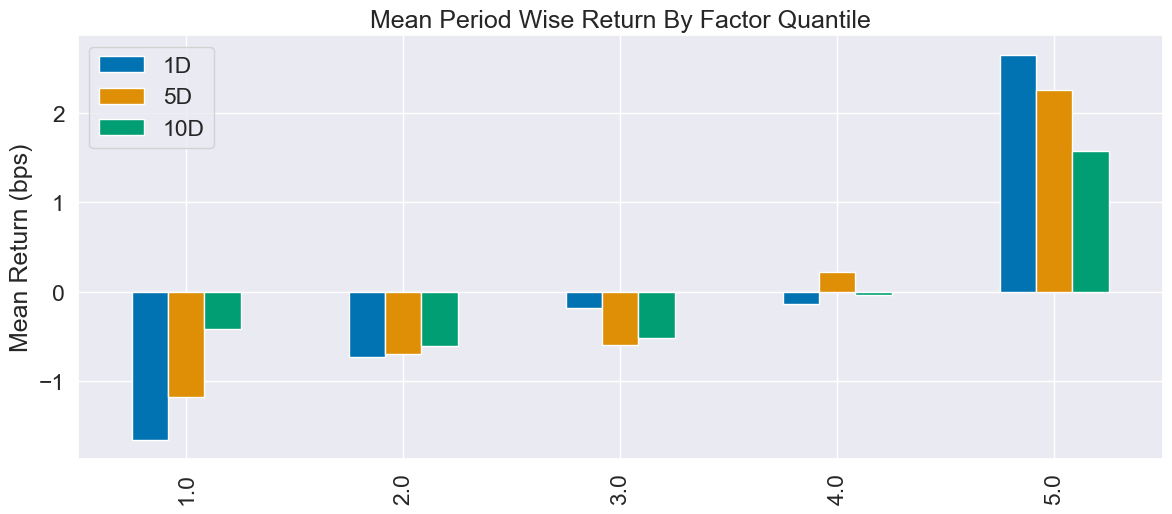

In [32]:
# Cell 5: Alphalens Evaluation
import traceback
evaluator = FactorEvaluator()

try:
    # Call format_for_alphalens to get clean_factor_data
    clean_factor_data = evaluator.format_for_alphalens(filtered_reversal, price_df)
    
    # Call generate_summary_tear_sheet to display results
    print("Generating Alphalens Summary Tear Sheet...")
    evaluator.generate_summary_tear_sheet(clean_factor_data)
    
except Exception as e:
    traceback.print_exc()
    print(f"Error during evaluation: {e}")

Calculating and stacking factors...
Combining into correlation matrix...


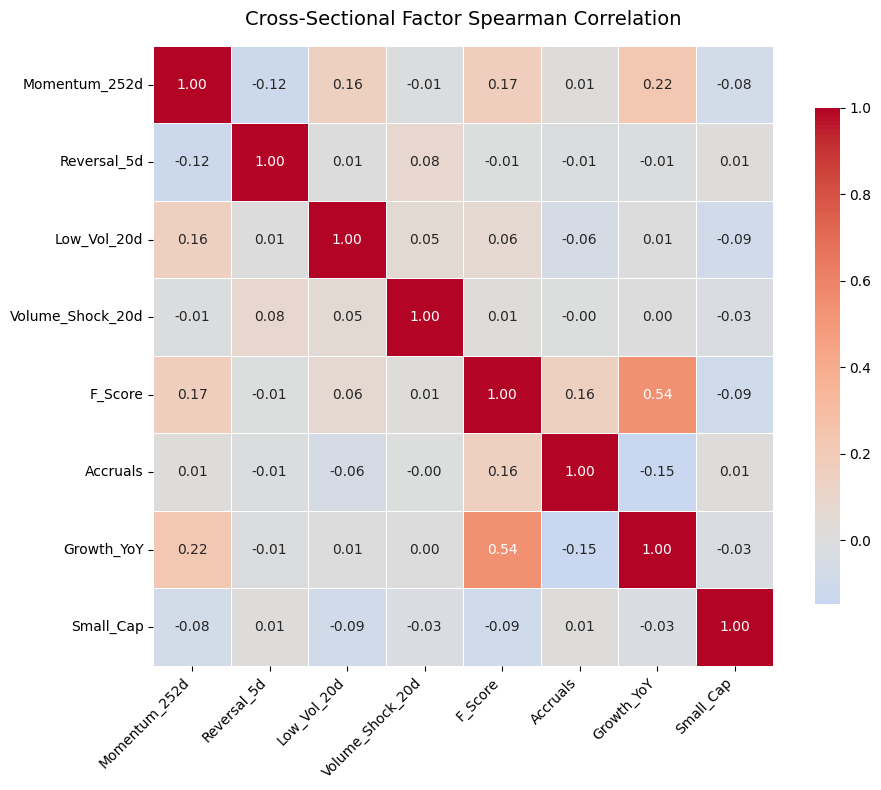

In [33]:
# Cell: Factor Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Import Factors
from factors.momentum.ts_momentum import TimeSeriesMomentum
from factors.momentum.reversal import ShortTermReversal
from factors.risk.volatility import HistoricalVolatility
from factors.volume.volume_shock import VolumeShock
from factors.fundamental.f_score import PiotroskiFScore
from factors.fundamental.accruals import Accruals
from factors.fundamental.growth_yoy import ProfitabilityGrowth
from factors.fundamental.size import SmallCap
from core.data_fetcher.aligner import CrossSectionAligner

# Instantiate Factors
factor_generators = {
    'Momentum_252d': TimeSeriesMomentum(252),
    'Reversal_5d': ShortTermReversal(5),
    'Low_Vol_20d': HistoricalVolatility(20),
    'Volume_Shock_20d': VolumeShock(20),
    'F_Score': PiotroskiFScore(),
    'Accruals': Accruals(),
    'Growth_YoY': ProfitabilityGrowth(),
    'Small_Cap': SmallCap()
}

aligner = CrossSectionAligner()
stacked_factors = []

print("Calculating and stacking factors...")
for factor_name, factor_instance in factor_generators.items():
    factor_dict = {}
    
    # Calculate factor for each ticker
    for ticker, df in data_dict.items():
        try:
            factor_dict[ticker] = factor_instance.compute(df)
        except Exception as e:
            # Skip tickers that might not have enough data for a specific factor
            continue
            
    # Align cross-sectionally
    aligned_df = aligner.align_factors(factor_dict)
    
    # Stack into a long Series: MultiIndex (Date, Ticker)
    stacked_series = aligned_df.stack()
    stacked_series.index.names = ['date', 'ticker']
    stacked_series.name = factor_name
    
    stacked_factors.append(stacked_series)

# Combine into a single DataFrame
print("Combining into correlation matrix...")
combined_factors_df = pd.concat(stacked_factors, axis=1)

# Compute Spearman rank correlation
corr_matrix = combined_factors_df.corr(method='spearman')

# Plotting the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    center=0, 
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)
plt.title("Cross-Sectional Factor Spearman Correlation", fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Preparing factor datasets for ML...
Training LightGBM model (Train period: <= 2025-01-01, Test period: > 2025-01-01)...
Training LightGBM model on 1778318 samples...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004850 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1796
[LightGBM] [Info] Number of data points in the train set: 1778318, number of used features: 8
[LightGBM] [Info] Start training from score 0.003008
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

/Users/bytedance/workspace/factor_investment/venv/lib/python3.9/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change(period)


Dropped 1.7% entries from factor data: 1.7% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.045616,0.002075,0.000028,0.002656,29198,20.124061
2,-0.000184,0.003560,0.001349,0.000412,28897,19.916603
3,0.000804,0.004636,0.001997,0.000496,28943,19.948308
4,0.001238,0.008716,0.002898,0.000765,28897,19.916603
5,0.002194,0.112600,0.007022,0.007424,29155,20.094424


Returns Analysis


...

,1D,5D,10D
IC Mean,0.011,0.016,0.017
IC Std.,0.160,0.153,0.143
Risk-Adjusted IC,0.066,0.107,0.117
t-stat(IC),1.118,1.815,1.987
p-value(IC),0.265,0.071,0.048
IC Skew,0.096,0.202,0.385
IC Kurtosis,0.273,0.760,0.107


Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.285,0.586,0.624
Quantile 2 Mean Turnover,0.487,0.712,0.727
Quantile 3 Mean Turnover,0.511,0.726,0.747
Quantile 4 Mean Turnover,0.444,0.694,0.716
Quantile 5 Mean Turnover,0.217,0.426,0.457


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.837,0.504,0.462


<Figure size 640x480 with 0 Axes>

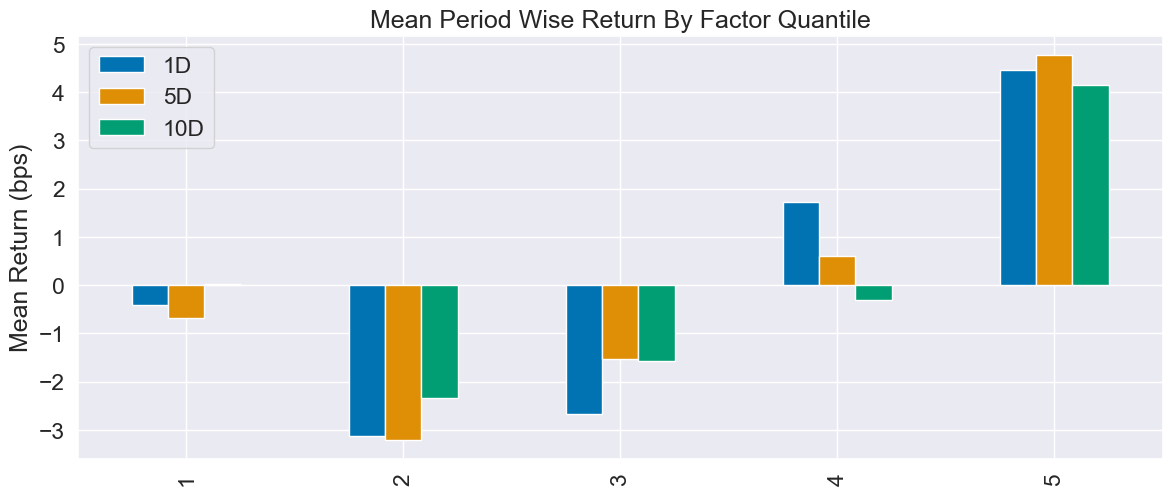

In [ ]:
# ==========================================
# 终极决战：LightGBM 机器学习多因子合成 (Out-of-Sample)
# ==========================================
from portfolio.ml_combiner import TreeFactorCombiner

print("Preparing factor datasets for ML...")
# 1. 整理特征字典：提取我们刚才算好的 8 个对齐后的因子 DataFrame
factor_dfs = {}
for factor_name, factor_instance in factor_generators.items():
    # 这里我们重新计算并对齐一次，确保数据格式干净
    raw_factor_dict = {ticker: factor_instance.compute(df) for ticker, df in data_dict.items()}
    factor_dfs[factor_name] = aligner.align_factors(raw_factor_dict)

# 2. 实例化 LightGBM 合成器
# 假设我们的数据一直到 2026 年初，我们用 2025-01-01 作为分水岭。
# 2025年之前的数据用来训练模型，2025年之后的数据用来做严格的样本外测试！
split_date = '2025-01-01'
ml_combiner = TreeFactorCombiner(train_end_date=split_date, forward_period=5)

print(f"Training LightGBM model (Train period: <= {split_date}, Test period: > {split_date})...")
# 3. 训练模型并输出测试集的预测得分
# 这步可能需要几秒到十几秒，取决于你的 CPU 性能
ml_predictions_df = ml_combiner.train_and_predict(factor_dfs, price_df)

print("\nModel trained successfully! Generating Out-of-Sample Tear Sheet...")
# 4. 把模型的预测得分（本身就是最强的综合 Alpha 因子）丢进 Alphalens！
clean_ml_data = evaluator.format_for_alphalens(ml_predictions_df, price_df)
evaluator.generate_summary_tear_sheet(clean_ml_data)

/var/folders/d3/t6zp9lzj2db6tykxcjlbt95c0000gn/T/ipykernel_53134/41380784.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Factor', data=importance_df, palette='viridis')


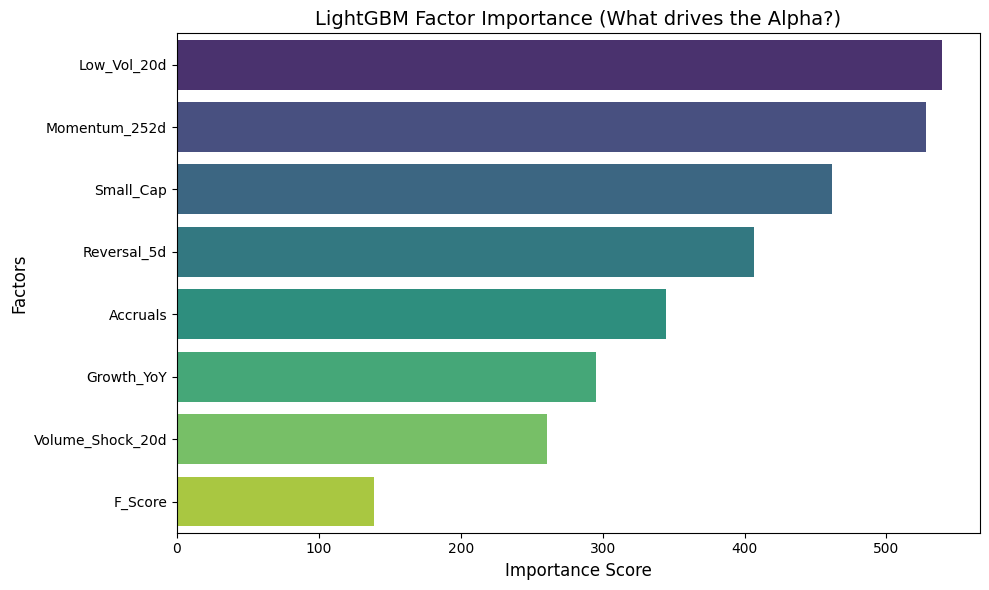

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 假设你的 ml_combiner 内部保存了训练好的模型为 ml_combiner.model
# 并且特征列名可以从 factor_dfs 的键中获取
feature_names = list(factor_dfs.keys())

try:
    # 提取特征重要性 (Split 或 Gain)
    importances = ml_combiner.model.feature_importances_
    
    # 组合成 DataFrame 方便画图
    importance_df = pd.DataFrame({
        'Factor': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    # 画图
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Factor', data=importance_df, palette='viridis')  
    plt.title('LightGBM Factor Importance (What drives the Alpha?)', fontsize=14)
    plt.xlabel('Importance Score', fontsize=12)
    plt.ylabel('Factors', fontsize=12)
    plt.tight_layout()
    plt.show()
    
except AttributeError as e:
    print(f"模型可能没有作为属性保存在 ml_combiner 中。请检查 ml_combiner.py 中的代码，确保有 self.model = model 这一行。错误信息: {e}")
